In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Dataset .csv")
print(df.columns)
cuisine_combinations = df["Cuisines"].value_counts()

print(cuisine_combinations.head(10))

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


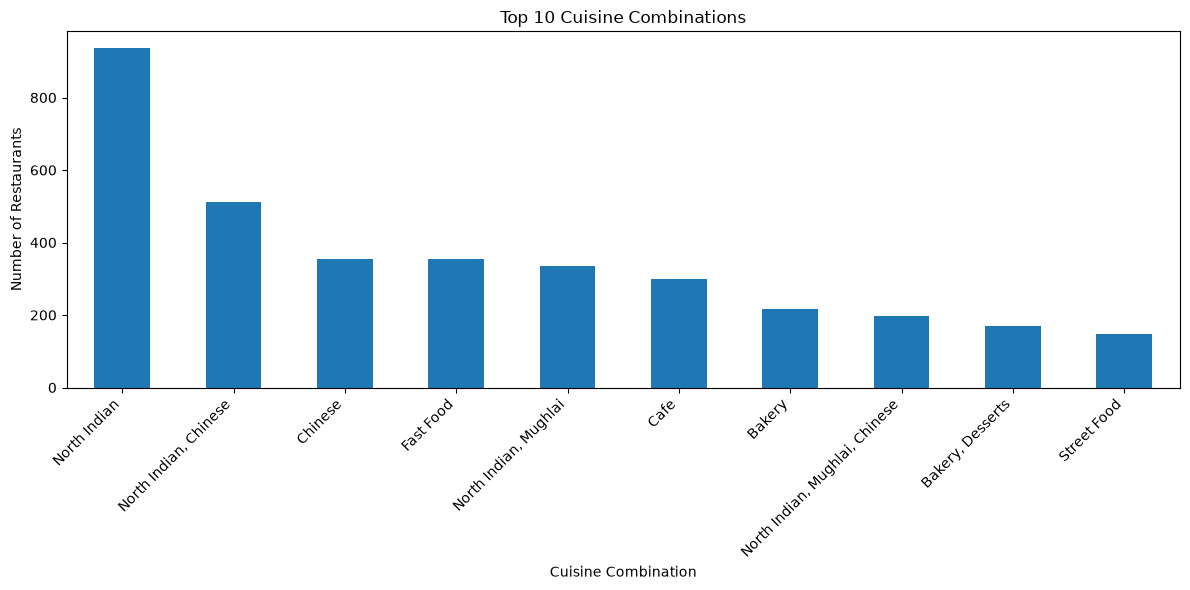

In [2]:
top10 = cuisine_combinations.head(10)

plt.figure(figsize=(12,6))
top10.plot(kind="bar")

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("Top10_Cuisine_Combinations.png")
plt.show()

In [3]:
average_rating = df.groupby("Cuisines")["Aggregate rating"].mean().round(2)

print(average_rating.sort_values(ascending=False).head(10))

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


In [5]:
cuisine_stats = df.groupby("Cuisines").agg(
    Average_Rating=("Aggregate rating", "mean"),
    Restaurant_Count=("Cuisines", "count")
)

top_rated = cuisine_stats[cuisine_stats["Restaurant_Count"] >= 10]

top_rated = top_rated.sort_values(
    by="Average_Rating",
    ascending=False
)

print(top_rated.head(10))

                            Average_Rating  Restaurant_Count
Cuisines                                                    
Modern Indian                     4.345455                11
Indian                            4.250000                18
Seafood                           4.114286                14
Thai                              4.100000                16
Cafe, Continental, Italian        4.080000                10
American, Burger                  4.076923                13
Japanese, Sushi                   4.044444                18
Pizza, Italian                    3.668421                19
American                          3.667742                31
Italian                           3.657407                54


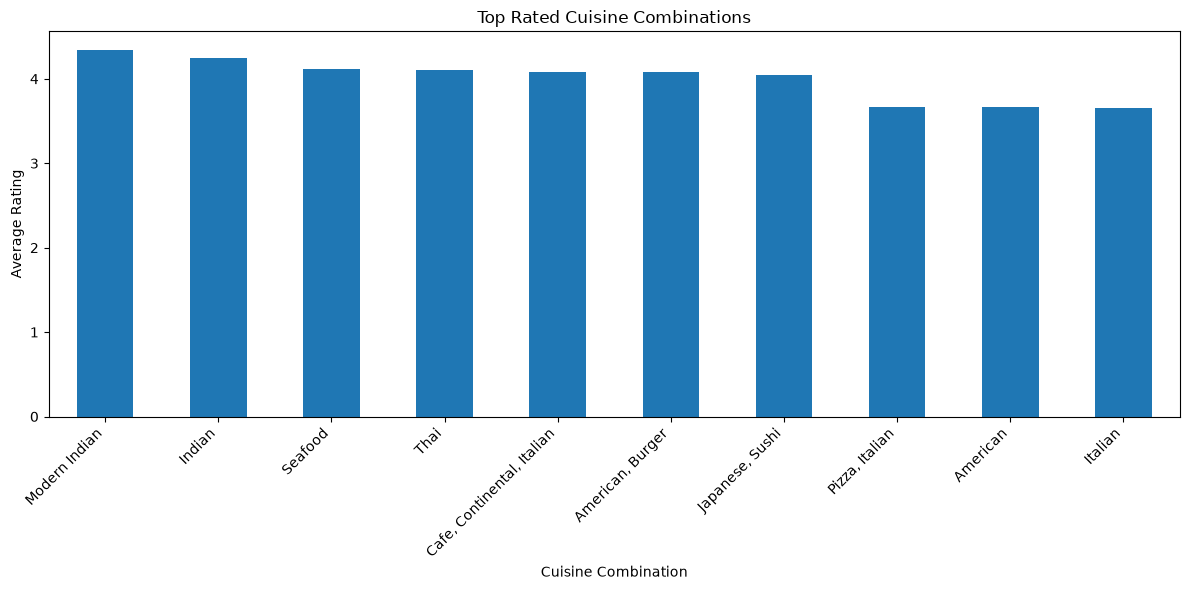

In [6]:
top10_rated = top_rated.head(10)

plt.figure(figsize=(12,6))
top10_rated["Average_Rating"].plot(kind="bar")

plt.title("Top Rated Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("Top_Rated_Cuisine_Combinations.png")
plt.show()